In [82]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from astropy.table import Table
import pickle
import pandas as pd
import SyntheticData as sd
import Sampler
from datetime import datetime, date
from matplotlib import colors
import corner

In [2]:
import style

## A test

In [3]:
indata = pickle.load(open("./massive_data/2026-01-20-reference.pkl", "rb"))
data_const_fb = indata["data"]
sc_cubes = pickle.load(open("./data/2026-01-26-mdwarf_mbins_3plx_turnover.pkl", "rb"))

In [4]:
synthdata = np.array(data_const_fb)
soltypes = np.zeros(len(synthdata), dtype=np.int8)
for i in range(len(soltypes)):
    soltypes[i] = synthdata[i]["solution_type"] 
    
rates = [len(soltypes[soltypes == soltype])/len(synthdata)*100 for soltype in [0,5,7,9,12]]
grid = [
    rates,
    [int(grp/100*len(synthdata)) for grp in rates]
]
row_labels = ["Rate (%)", "Counts"]
col_labels = ["low RUWE", "high RUWE", "Acceleration", "Jerk", "Full Orbit"]
pd.DataFrame(grid, index=row_labels, columns=col_labels)

,low RUWE,high RUWE,Acceleration,Jerk,Full Orbit
Rate (%),95.1852,3.7896,0.6612,0.1496,0.2144
Counts,237963.0000,9474.0000,1653.0000,374.0000,536.0000


In [5]:
indices = [0,5,7,9,12]
working_catalogue = []
relevant_list = ["parallax", "mass", "solution_type", "is_binary"]
masses = np.array([row["mass"] for row in data_const_fb])
percs = np.percentile(masses, np.arange(0, 110, 10))
qs = []
for row in tqdm(data_const_fb):
    keep = True
    if row["is_binary"]:
        if row["period"] > 1e5: # cut at 1e4
            keep = False
        else:
            qs.append(row["q"])
    if keep:
        df = dict()
        df["soltype_index"] = indices.index(row["solution_type"])   
        df["mass_index"] = np.minimum(np.digitize(row["mass"], percs) - 1, 9)
        for item in relevant_list:
            df[item] = float(row[item])
    working_catalogue.append(df)
working_catalogue = np.array(working_catalogue)

  0%|          | 0/250000 [00:00<?, ?it/s]

In [6]:
fb = 0.3
x = fb - (Sampler.area_in_range((5,8), 4, 1.3)/Sampler.area_in_range((1,8), 4, 1.3))*fb
x/(1-fb+x)

np.float64(0.24995324751058642)

In [59]:
small_catalogue = np.random.choice(working_catalogue, 50000)
model_cube = Sampler.create_model_cube((50,35), p_model=(4,1.3), q_model=0.5)
synthsampler = Sampler.popsampler(sc_cubes, small_catalogue, model_cube=model_cube)
grids = synthsampler.assign_grids(small_catalogue, p_range=(1,8), q_range=(0.05,0.5), mass_binned=True, scale=10)

  0%|          | 0/50000 [00:00<?, ?it/s]

In [63]:
fit_fb = len(small_catalogue[[w["is_binary"]==1 for w in small_catalogue]])/len(small_catalogue)
fit_fb

0.2517

In [64]:
gammas, likelihoods_l = synthsampler.q_along_grid(p_model=(4,1.3), fb=fit_fb, pcut=5,
                            p_range=(1,8), q_range=(0.05,0.5), cutoff=np.exp(-25), 
                            grids=grids, catalogue=small_catalogue, model_cube=model_cube, mass_binned=True, scale=10, verbose=True)

Reducing catalogue...
Calculating likelihoods...


  0%|          | 0/1000 [00:00<?, ?it/s]

Complete!


In [65]:
gammas, likelihoods_h = synthsampler.q_along_grid(p_model=(4,1.3), fb=0.28, pcut=5,
                            p_range=(1,8), q_range=(0.05,0.5), cutoff=np.exp(-25), 
                            grids=grids, catalogue=small_catalogue, model_cube=model_cube, mass_binned=True, scale=10, verbose=True)

Reducing catalogue...
Calculating likelihoods...


  0%|          | 0/1000 [00:00<?, ?it/s]

Complete!


(-3.0, 0.5)

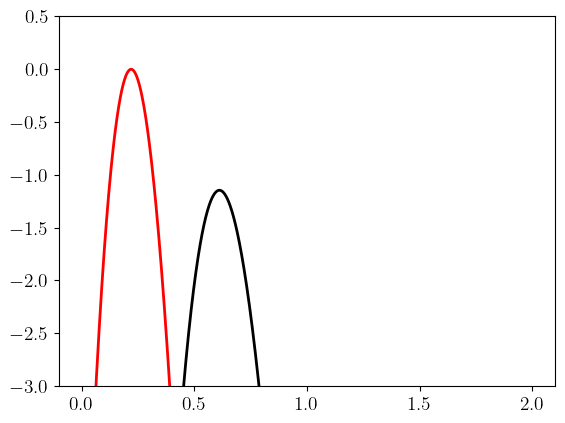

In [66]:
plt.plot(gammas, likelihoods_l-np.max(likelihoods_h), c="k", lw=2);
plt.plot(gammas, likelihoods_h-np.max(likelihoods_h), c="r", lw=2);
#plt.ylim(bottom=-11465, top=-11460)
plt.ylim(bottom=-3, top=0.5)

In [67]:
synthsampler.constrain_parameters(p_model=(4,1.3), step_count=500, nwalkers=6,
                                 p_range=(1,8), q_range=(0.05,0.5), cutoff=np.exp(-25), 
                                grids=grids, catalogue=small_catalogue, model_cube=model_cube, mass_binned=True, scale=10, verbose=True)

Reducing catalogue...
Running markov chains...


100%|██████████| 500/500 [1:26:32<00:00, 10.38s/it]

Complete!


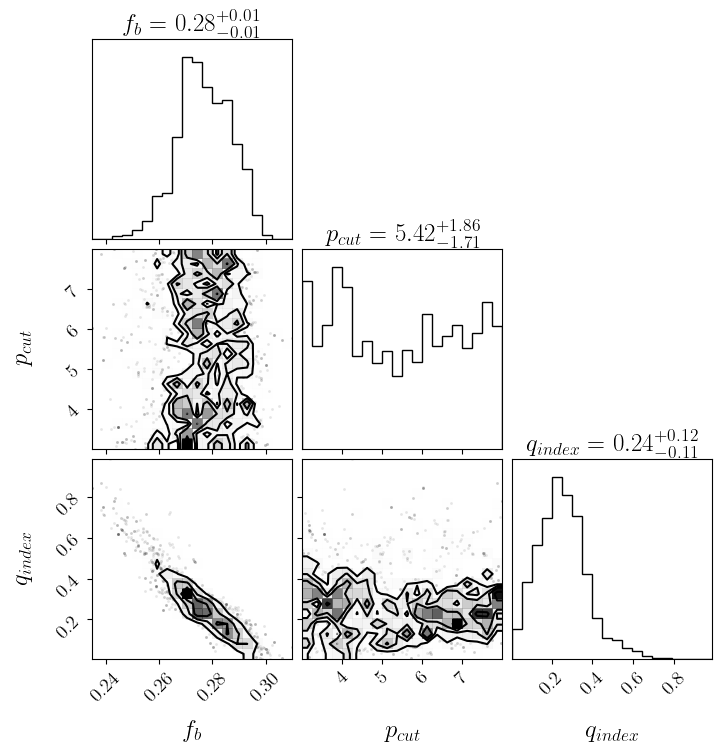

In [69]:
import corner
discard = 200
chain = synthsampler.sampler.get_chain(discard=discard, flat=True)
likelihoods = synthsampler.sampler.get_log_prob(discard=discard, flat=True) 
corner.corner(chain, weights=np.exp(likelihoods - np.max(likelihoods)), show_titles=True, show_percentiles=True,
              labels=["$f_b$", "$p_{cut}$", "$q_{index}$"]);
              #truths=[fit_fb, 5, 0.5]);

In [24]:
ps = np.linspace(3,8, 1000)
pps = Sampler.gaussian(ps, 4, 1.3)
pps = pps / np.trapz(pps, ps)

/tmp/ipykernel_998186/1101874272.py:3: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  pps = pps / np.trapz(pps, ps)


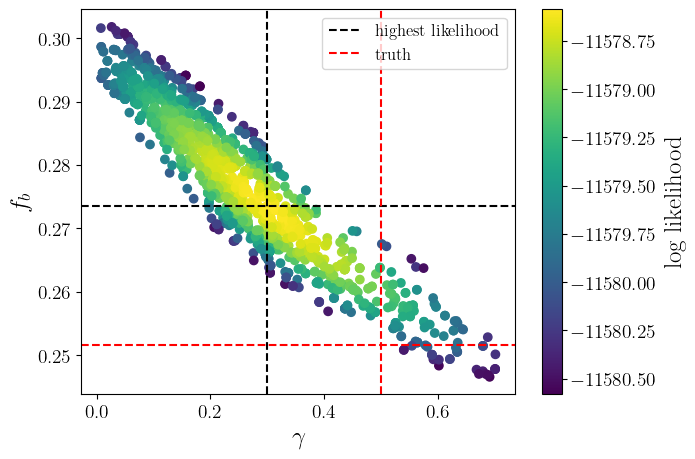

In [71]:
fig, ax = plt.subplots(1,1, figsize=(7,5))

check_indices = [0,2]
param_names = ["$f_b$", "$T_\\text{cutoff}$", "$\gamma$"]

likelihood_cutoff = np.max(likelihoods) - 2
new_chain = chain[likelihoods > likelihood_cutoff]
new_likelihoods = likelihoods[likelihoods > likelihood_cutoff]

cb = ax.scatter(new_chain[:,check_indices[1]], new_chain[:,check_indices[0]], c=new_likelihoods, cmap='viridis', norm=colors.Normalize())
plt.colorbar(cb, label="log likelihood")
ax.set_xlabel(param_names[check_indices[1]]);
ax.set_ylabel(param_names[check_indices[0]]);
max_x, max_y = new_chain[:,check_indices[1]][np.argmax(new_likelihoods)], new_chain[:,check_indices[0]][np.argmax(new_likelihoods)]
ax.axvline(max_x, c="k", linestyle="--", label="highest likelihood");
ax.axhline(max_y, c="k", linestyle="--");

ax.axvline(0.5, c="r", linestyle="--", label="truth");
ax.axhline(fit_fb, c="r", linestyle="--");
ax.legend(fontsize=12);

# ax2 = ax.twinx()
# ax2.plot(ps, np.cumsum(pps) * (ps[1] - ps[0]), color="k", linewidth=3);
# ax2.set_ylim(bottom=0.05);
# ax2.set_yticks([]);

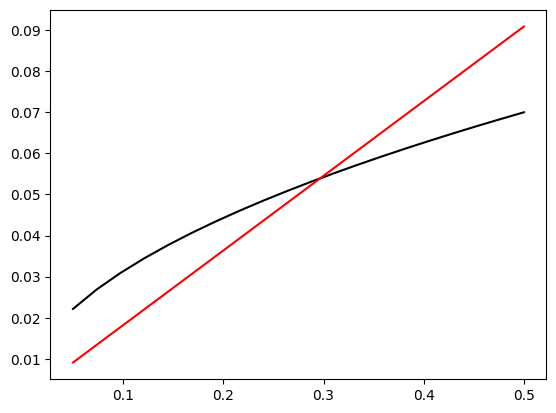

In [59]:
qs = np.linspace(0.05, 0.5, 20)
p5 = Sampler.pexp(qs, 0.5, val_range=(0.05,0.5), ignore_a=True)
p1 = Sampler.pexp(qs, 1, val_range=(0.05,0.5), ignore_a=True)
plt.plot(qs, p5/np.sum(p5), c="k");
plt.plot(qs, p1/np.sum(p1), c="r");

## A frankenstein's monster dataset
take all the $M<0.3$ objects from the $\gamma=0$ dataset, and the $M>0.3$ objects from the $\gamma=1$ dataset. See if we constrain meaningfully different power law slope.

In [78]:
indata_0 = pickle.load(open("./massive_data/2026-01-31-flat_q.pkl", "rb"))["data"]
indata_1 = pickle.load(open("./massive_data/2026-01-31-gamma1.pkl", "rb"))["data"]

sc_cubes = pickle.load(open("./data/2026-01-26-mdwarf_mbins_3plx_turnover.pkl", "rb"))

indices = [0,5,7,9,12]
relevant_list = ["parallax", "mass", "solution_type", "is_binary"]

masses_0 = np.array([row["mass"] for row in indata_0])
percs_0 = np.percentile(masses_0, np.arange(0, 110, 10))
catalogue_0 = []
for row in tqdm(indata_0):
    keep = False
    if row["mass"] < 0.3:
        keep = True
    if row["is_binary"]:
        if row["period"] > 1e5: # cut at 1e4
            keep = False
    if keep:
        df = dict()
        df["soltype_index"] = indices.index(row["solution_type"])   
        df["mass_index"] = np.minimum(np.digitize(row["mass"], percs) - 1, 9)
        for item in relevant_list:
            df[item] = float(row[item])
        catalogue_0.append(df)

masses_1 = np.array([row["mass"] for row in indata_1])
percs_1 = np.percentile(masses_1, np.arange(0, 110, 10))
catalogue_1 = []
for row in tqdm(indata_1):
    keep = False
    if row["mass"] > 0.3:
        keep = True
    if row["is_binary"]:
        if row["period"] > 1e5: # cut at 1e4
            keep = False
    if keep:
        df = dict()
        df["soltype_index"] = indices.index(row["solution_type"])   
        df["mass_index"] = np.minimum(np.digitize(row["mass"], percs) - 1, 9)
        for item in relevant_list:
            df[item] = float(row[item])
        catalogue_1.append(df)
    
catalogue_0 = np.array(catalogue_0)
catalogue_1 = np.array(catalogue_1)

  0%|          | 0/50000 [00:00<?, ?it/s]

  0%|          | 0/50000 [00:00<?, ?it/s]

In [79]:
len(catalogue_0), len(catalogue_1)

(15838, 30734)

In [80]:
model_cube = Sampler.create_model_cube((35,35), p_model=(4,1.3), q_model=0)
synthsampler = Sampler.popsampler(sc_cubes, catalogue_0, model_cube=model_cube)
grids = synthsampler.assign_grids(catalogue_0, p_range=(1,8), q_range=(0.05,0.5), mass_binned=True, scale=7)

synthsampler.constrain_parameters(p_model=(4,1.3), step_count=500, nwalkers=6,
                                 p_range=(1,8), q_range=(0.05,0.5), cutoff=np.exp(-25), 
                                grids=grids, catalogue=catalogue_0, model_cube=model_cube, mass_binned=True, scale=7, verbose=True)

  0%|          | 0/15838 [00:00<?, ?it/s]

Reducing catalogue...
Running markov chains...


100%|██████████| 500/500 [22:06<00:00,  2.65s/it]

Complete!


In [81]:
model_cube = Sampler.create_model_cube((35,35), p_model=(4,1.3), q_model=0)
synthsampler_1 = Sampler.popsampler(sc_cubes, catalogue_1, model_cube=model_cube)
grids = synthsampler_1.assign_grids(catalogue_1, p_range=(1,8), q_range=(0.05,0.5), mass_binned=True, scale=7)

synthsampler_1.constrain_parameters(p_model=(4,1.3), step_count=500, nwalkers=6,
                                 p_range=(1,8), q_range=(0.05,0.5), cutoff=np.exp(-25), 
                                grids=grids, catalogue=catalogue_1, model_cube=model_cube, mass_binned=True, scale=7, verbose=True)

  0%|          | 0/30734 [00:00<?, ?it/s]

Reducing catalogue...
Running markov chains...


100%|██████████| 500/500 [35:08<00:00,  4.22s/it]

Complete!


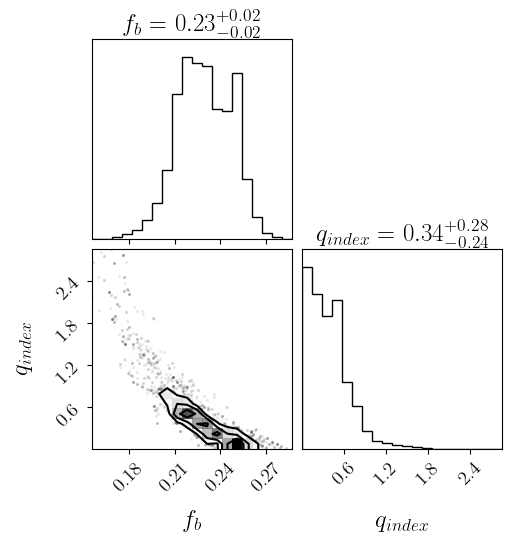

In [108]:
discard = 200

chain = synthsampler.sampler.get_chain(discard=discard, flat=True)
chain[:,0] = chain[:,0]*100
likelihoods = synthsampler.sampler.get_log_prob(discard=discard, flat=True) 
corner.corner(chain[:,[0,2]], weights=np.exp(likelihoods - np.max(likelihoods)), show_titles=True, show_percentiles=True,
              labels=["$f_b$", "$q_{index}$"]);

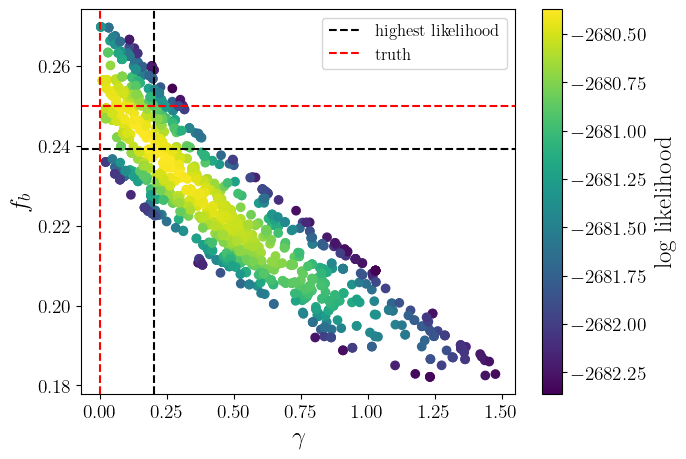

In [109]:
fig, ax = plt.subplots(1,1, figsize=(7,5))

check_indices = [0,2]
param_names = ["$f_b$", "$T_\\text{cutoff}$", "$\gamma$"]

likelihood_cutoff = np.max(likelihoods) - 2
new_chain = chain[likelihoods > likelihood_cutoff]
new_likelihoods = likelihoods[likelihoods > likelihood_cutoff]

cb = ax.scatter(new_chain[:,check_indices[1]], new_chain[:,check_indices[0]], c=new_likelihoods, cmap='viridis', norm=colors.Normalize())
plt.colorbar(cb, label="log likelihood")
ax.set_xlabel(param_names[check_indices[1]]);
ax.set_ylabel(param_names[check_indices[0]]);
max_x, max_y = new_chain[:,check_indices[1]][np.argmax(new_likelihoods)], new_chain[:,check_indices[0]][np.argmax(new_likelihoods)]
ax.axvline(max_x, c="k", linestyle="--", label="highest likelihood");
ax.axhline(max_y, c="k", linestyle="--");

ax.axvline(0, c="r", linestyle="--", label="truth");
ax.axhline(0.25, c="r", linestyle="--");
ax.legend(fontsize=12);

# ax2 = ax.twinx()
# ax2.plot(ps, np.cumsum(pps) * (ps[1] - ps[0]), color="k", linewidth=3);
# ax2.set_ylim(bottom=0.05);
# ax2.set_yticks([]);

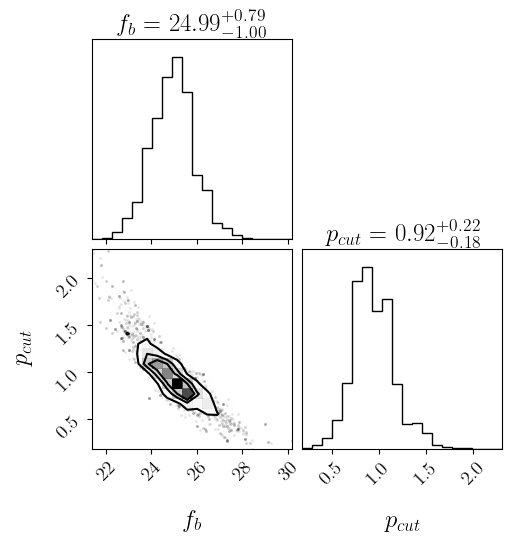

In [105]:
discard = 200
chain = synthsampler_1.sampler.get_chain(discard=discard, flat=True)
chain[:,0] = chain[:,0]*100
likelihoods = synthsampler_1.sampler.get_log_prob(discard=discard, flat=True) 
corner.corner(chain[:,[0,2]], weights=np.exp(likelihoods - np.max(likelihoods)), show_titles=True, show_percentiles=True,
              labels=["$f_b$", "$p_{cut}$", "$q_{index}$"]);
              #truths=[fit_fb, 5, 0.5]);

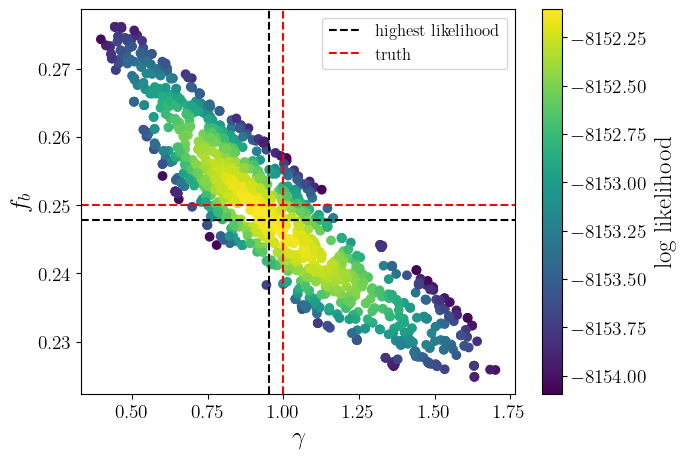

In [102]:
fig, ax = plt.subplots(1,1, figsize=(7,5))

check_indices = [0,2]
param_names = ["$f_b$", "$T_\\text{cutoff}$", "$\gamma$"]

likelihood_cutoff = np.max(likelihoods) - 2
new_chain = chain[likelihoods > likelihood_cutoff]
new_likelihoods = likelihoods[likelihoods > likelihood_cutoff]

cb = ax.scatter(new_chain[:,check_indices[1]], new_chain[:,check_indices[0]], c=new_likelihoods, cmap='viridis', norm=colors.Normalize())
plt.colorbar(cb, label="log likelihood")
ax.set_xlabel(param_names[check_indices[1]]);
ax.set_ylabel(param_names[check_indices[0]]);
max_x, max_y = new_chain[:,check_indices[1]][np.argmax(new_likelihoods)], new_chain[:,check_indices[0]][np.argmax(new_likelihoods)]
ax.axvline(max_x, c="k", linestyle="--", label="highest likelihood");
ax.axhline(max_y, c="k", linestyle="--");

ax.axvline(1, c="r", linestyle="--", label="truth");
ax.axhline(0.25, c="r", linestyle="--");
ax.legend(fontsize=12);

# ax2 = ax.twinx()
# ax2.plot(ps, np.cumsum(pps) * (ps[1] - ps[0]), color="k", linewidth=3);
# ax2.set_ylim(bottom=0.05);
# ax2.set_yticks([]);